# 📝 Problem Description

This project uses a public Mercado Libre dataset with 100,000 product listings in JSON Lines format.


## 🔍 Initial Exploration of the Dataset

Before diving into feature engineering and modeling, it is important to understand the structure of the dataset. 
In this step, we will examine:

- All column names and their data types
- The number of rows and columns
- The amount of missing data in each column
- Basic descriptive statistics for numerical features

This gives us a clear overview of the dataset and helps guide further analysis.


# Dataset Columns Overview

The dataset contains **48 variables**, which capture different aspects of each product listing in the Mercado Libre marketplace. These include seller information, product details, pricing, shipping, and metadata. Below is a summary of all columns and their data types:


In [4]:
import pandas as pd

# Load the dataset
df = pd.read_json("MLA_100k.jsonlines", lines=True)

# Show all columns and their data types in a table
col_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": [df[col].dtype for col in df.columns]
})

# Display all rows (all columns) without truncation
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(col_info)



,Column,Data Type
0,seller_address,object
1,warranty,object
2,sub_status,object
3,condition,object
4,seller_contact,object
5,deal_ids,object
6,base_price,float64
7,shipping,object
8,non_mercado_pago_payment_methods,object
9,seller_id,int64


In [12]:
import pandas as pd

# Load dataset
df = pd.read_json("MLA_100k.jsonlines", lines=True)

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create a summary table for outliers
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)].shape[0]
    
    # Handle empty or non-computable columns
    if pd.isna(lower_limit) or pd.isna(upper_limit):
        lower_limit = "N/A"
        upper_limit = "N/A"
    
    outlier_summary.append({
        "Column": col,
        "Outliers": outliers,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit
    })

outlier_df = pd.DataFrame(outlier_summary)

# Display nicely
display(outlier_df)



,Column,Outliers,Lower Limit,Upper Limit
0,base_price,14635,-975.0,1865.0
1,seller_id,0,-100009101.25,272110916.75
2,price,14636,-975.0,1865.0
3,official_store_id,0,-259.125,655.875
4,differential_pricing,0,N/A,N/A
5,original_price,18,-1127.5,3076.5
6,catalog_product_id,0,-28070.25,8181987.75
7,subtitle,0,N/A,N/A
8,initial_quantity,21220,-0.5,3.5
9,sold_quantity,16920,0.0,0.0


### Outlier Analysis Interpretation

We analyzed all numerical variables in the dataset to detect potential outliers using the Interquartile Range (IQR) method. Here's a summary of the findings:

- **`base_price` and `price`**: Both variables have a substantial number of outliers (~14,600 each). Some listings have extreme prices, possibly due to incorrect entries, promotions, or luxury items. The lower limits are negative, which is not realistic for prices, indicating data errors.  

- **`seller_id`, `official_store_id`, `catalog_product_id`, `subtitle`, `differential_pricing`**: These numeric variables have either no outliers or contain mostly identifiers, so extreme values are not necessarily errors. Some columns like `differential_pricing` and `subtitle` have NaN limits, meaning no IQR-based calculation is meaningful.  

- **`original_price`**: Has a few outliers (18) and some negative values, likely data entry errors.  

- **`initial_quantity` and `available_quantity`**: Show moderate numbers of outliers (~20,000). Negative values in these columns are invalid and should be reviewed.  

- **`sold_quantity`**: About 16,900 outliers exist. Most products have zero or low sold quantities, while some have significantly higher sales.  

**Conclusion:**  
This analysis highlights the need to handle anomalous or invalid data, particularly in price and quantity variables, before building a predictive model. Columns that are identifiers do not require correction.


### Outlier Analysis: Before Cleaning

The following boxplots show the distribution of numerical columns that contain outliers. 
Visualizing these outliers helps us understand which values are extreme and may distort 
the analysis or the model performance. 

Columns analyzed: `base_price`, `price`, `original_price`, `initial_quantity`, `sold_quantity`, `available_quantity`.


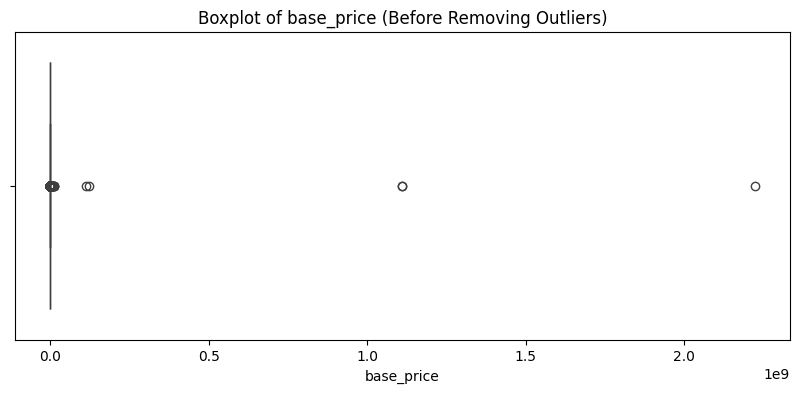

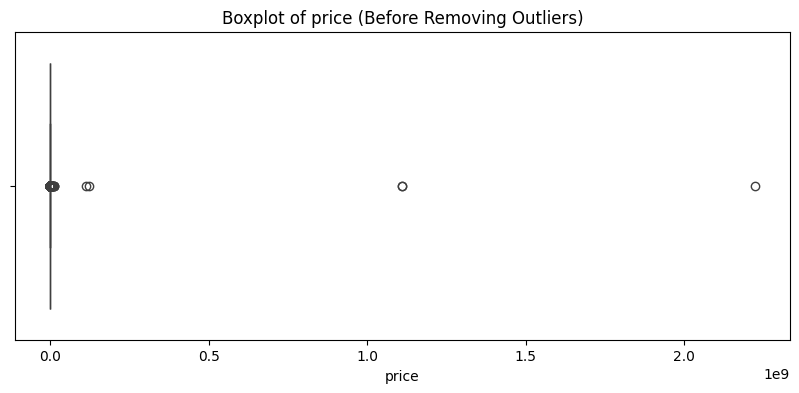

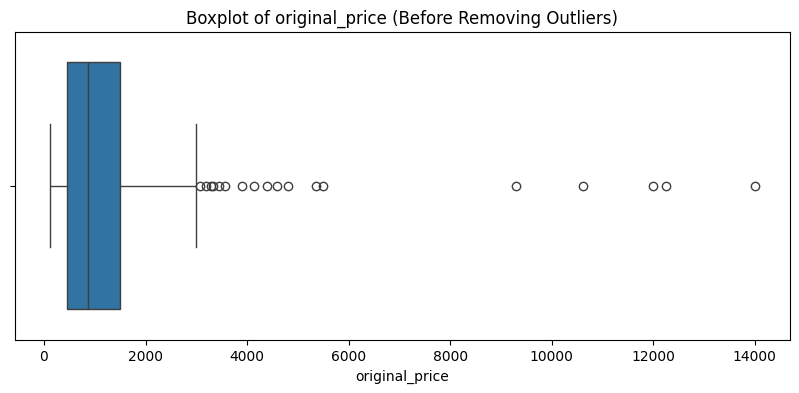

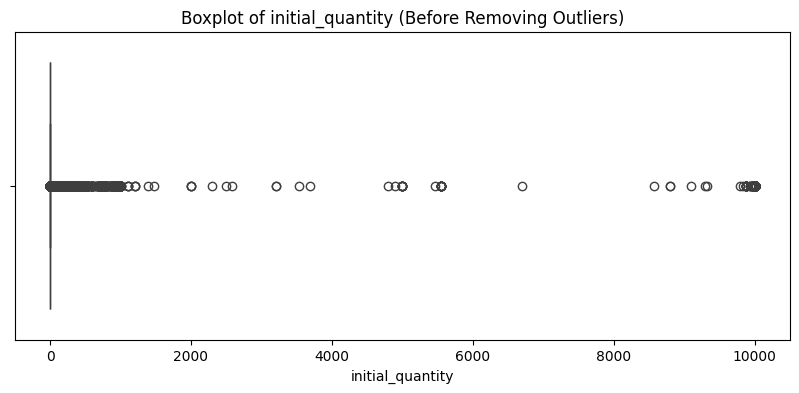

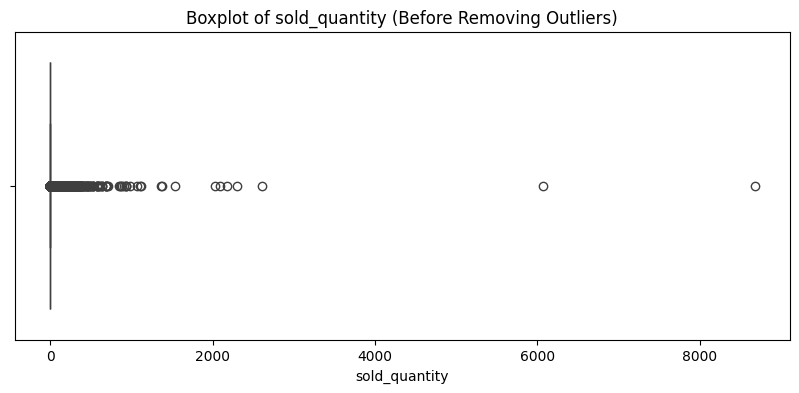

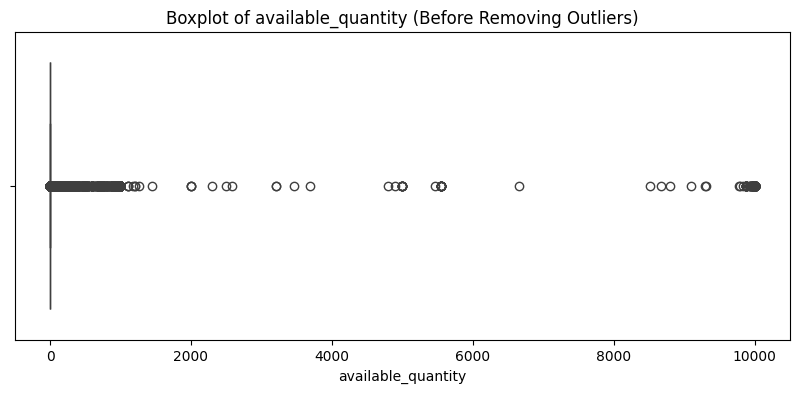

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns with detected outliers
num_outliers_cols = ['base_price', 'price', 'original_price', 'initial_quantity', 'sold_quantity', 'available_quantity']

# Visualize outliers before cleaning
for col in num_outliers_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} (Before Removing Outliers)')
    plt.show()


### Outlier Analysis: After Cleaning

We removed outliers using the IQR method (values beyond 1.5 times the interquartile range). 
The boxplots below show the numerical columns after this cleaning step, allowing us to 
assess the distributions more clearly without extreme values skewing the data.


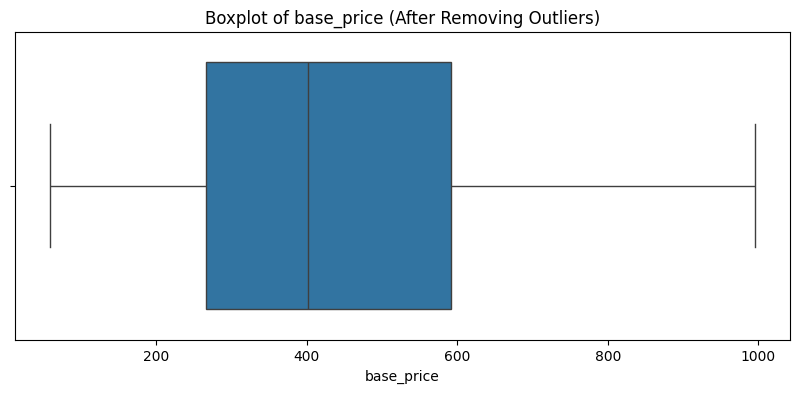

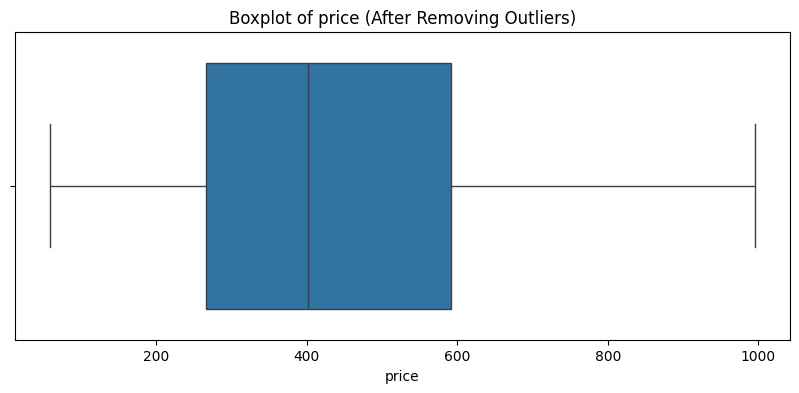

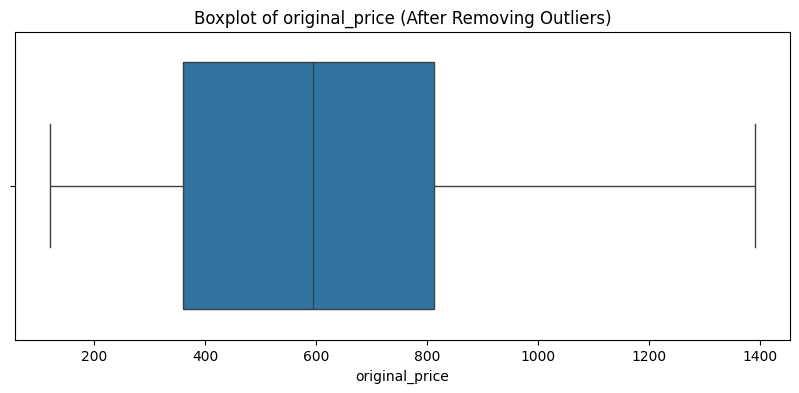

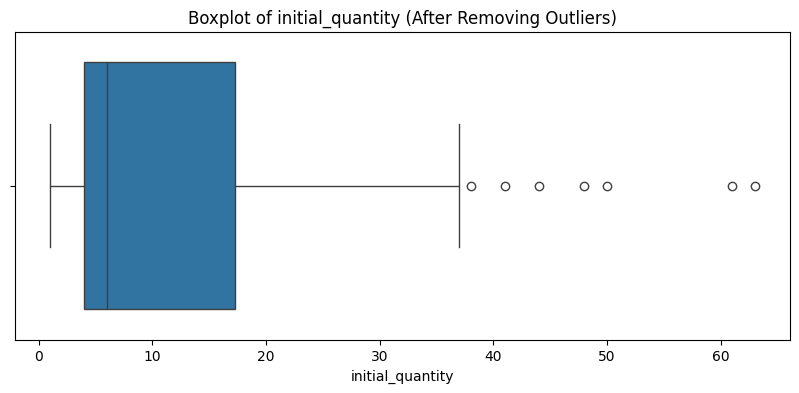

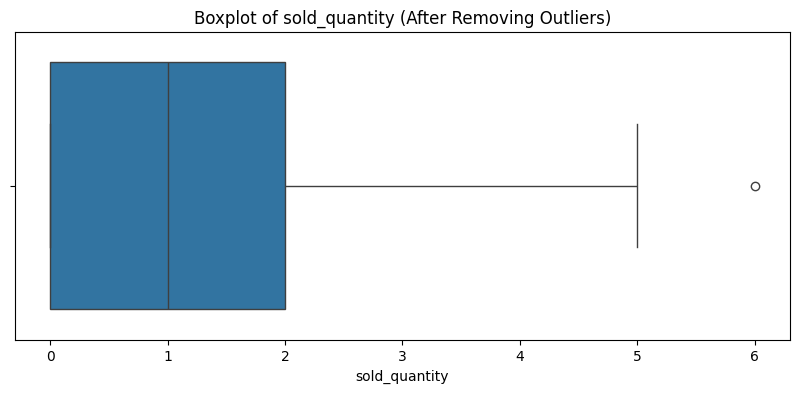

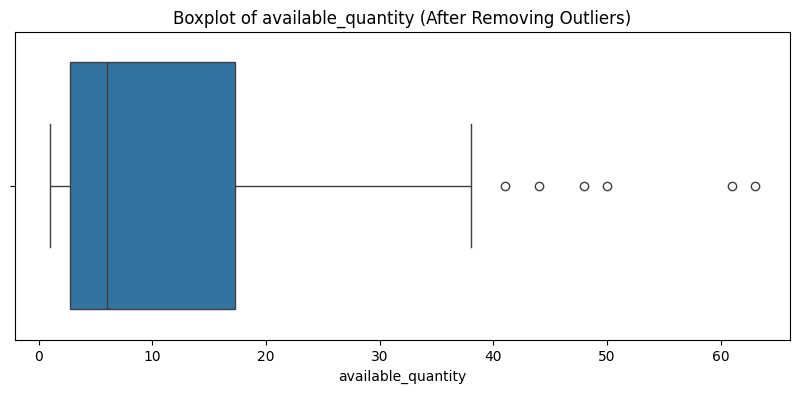

In [14]:
# Remove outliers using IQR method
for col in num_outliers_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

# Visualize after cleaning
for col in num_outliers_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} (After Removing Outliers)')
    plt.show()
